<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1fi3-l8zVpLJj3wj3peImenJzMWBHpo7E" width="850">
</p>


# Descargar Dataset

In [1]:
import gdown
import zipfile
import os

file_id = "1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6"
url = f"https://drive.google.com/uc?id={file_id}"
output_zip = "butterfly.zip"

gdown.download(url, output_zip, quiet=False)

extract_dir = "/content"
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

base_dir = os.path.join(extract_dir, "butterfly")
print("Contenido:", os.listdir(base_dir))


Downloading...
From: https://drive.google.com/uc?id=1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6
To: /content/butterfly.zip
100%|██████████| 6.43M/6.43M [00:00<00:00, 169MB/s]


Contenido: ['train', 'valid']


# Pre-procesamiento del dataset

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = "/content/butterfly"

train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=valid_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Clases:", classes)
print("Num imágenes train:", len(train_dataset))
print("Num imágenes valid:", len(valid_dataset))

num_classes = len(classes)
print("Número de clases:", num_classes)


Device: cuda
Clases: ['AFRICAN GIANT SWALLOWTAIL', 'BECKERS WHITE', 'CATTLEHEART CELLED GREEN', 'CHESTNUT', 'DAPPLE EASTERN WHITE', 'DIAETHRIA ANNA', 'GREY HAIRSTREAK']
Num imágenes train: 433
Num imágenes valid: 159
Número de clases: 7


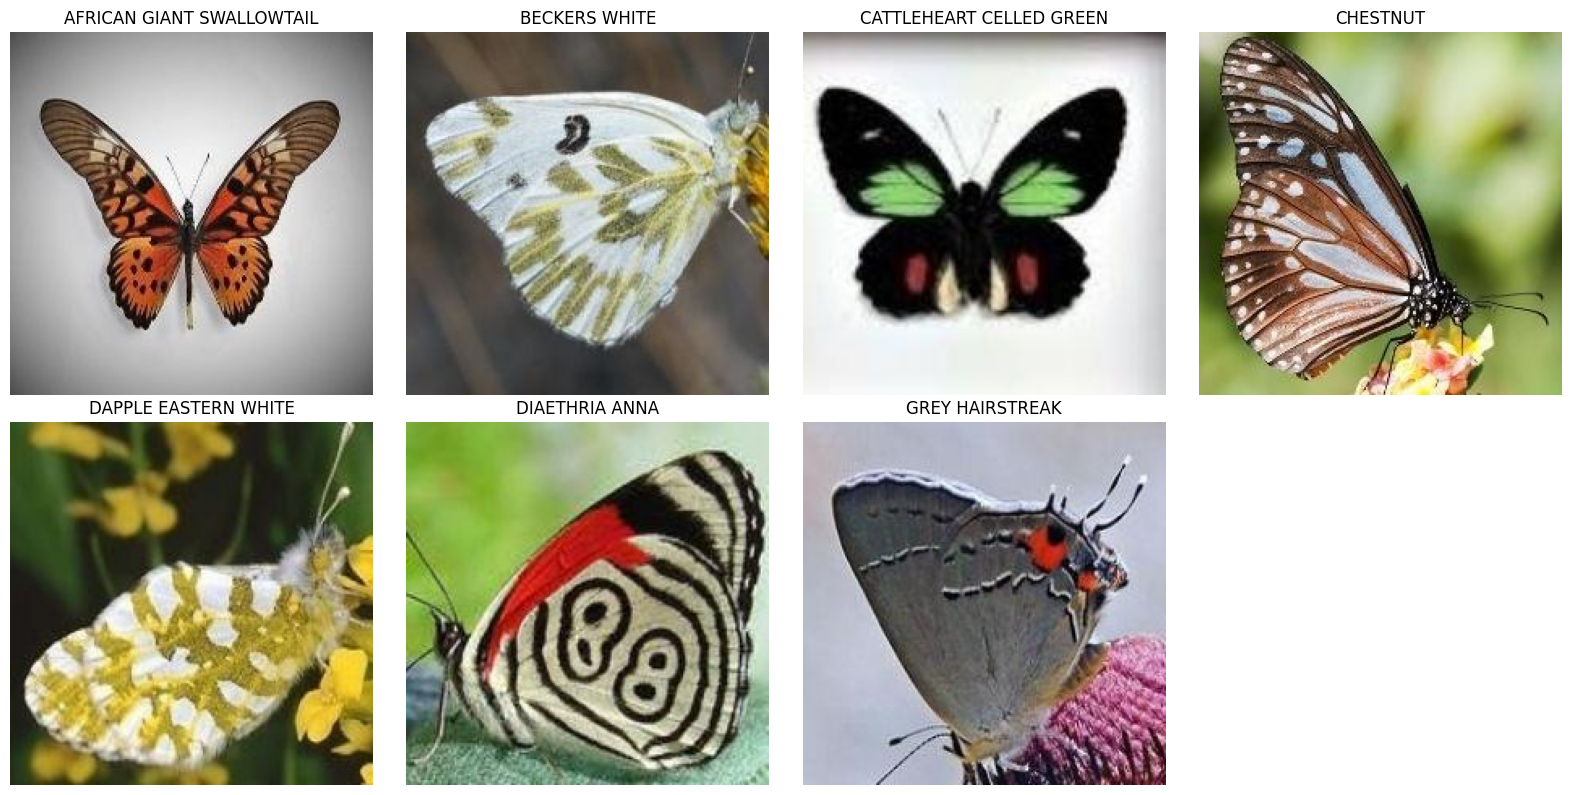

In [17]:
from PIL import Image

def show_random_images_per_class(dataset, transform, class_names):
    samples_per_class = {cls: [] for cls in class_names}

    for path, label in dataset.samples:
        samples_per_class[class_names[label]].append(path)

    num_classes = len(class_names)
    plt.figure(figsize=(16, 4 * ((num_classes + 3) // 4)))

    for idx, cls in enumerate(class_names):
        img_path = random.choice(samples_per_class[cls])
        img = Image.open(img_path).convert("RGB")

        img_tensor = transform(img)
        img_np = img_tensor.permute(1, 2, 0).numpy()

        plt.subplot((num_classes + 3)//4, 4, idx + 1)
        plt.imshow(img_np)
        plt.title(cls)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images_per_class(train_dataset, valid_transform, train_dataset.classes)


## Métodos para usar modelos pre-entrenados

In [4]:
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights # Importamos el modelo y sus parámetros

# ENTRENAMIENTO DESDE CERO:
# Iniciar con parámetros aleatorios
# Usamos solo la arquitectura del modelo
alexnet_random = alexnet(weights=None)
in_features = alexnet_random.classifier[-1].in_features
alexnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_random = alexnet_random.to(device)

# FINE-TUNING:
# Iniciar con parámetros obtenidos con ImageNet
# Usamos la arquitectura y los pesos del modelo, pero estos últimos los vamos a ajustar
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)

# FEATURE EXTRACTION:
# Iniciar con parámetros obtenidos con ImageNet y congelarlos
# Usaremos la arquitectura y los pesos del modelo, procurando dejar los pesos tal cual están
alexnet_fe = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
for p in alexnet_fe.parameters():
    p.requires_grad = False # Congela los pesos
in_features = alexnet_fe.classifier[-1].in_features
alexnet_fe.classifier[-1] = nn.Linear(in_features, num_classes)
for p in alexnet_fe.classifier[-1].parameters():
    p.requires_grad = True # Solo descongela los pesos de la última capa
alexnet_fe = alexnet_fe.to(device)


In [5]:
alexnet_model = alexnet(weights=None)
alexnet_model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

# Entrenamiento del modelo

In [6]:
import torch.optim as optim
from sklearn.metrics import f1_score

def entrenar_modelo(model, train_loader, val_loader, modo, num_epochs=10, lr=1e-3, device="cuda"):
    """
    Entrena un modelo PyTorch con seguimiento de métricas.

    Parámetros:
        model        -> instancia del modelo
        train_loader -> DataLoader para entrenamiento
        val_loader   -> DataLoader para validación
        modo         -> 0 para entrenamiento desde cero y feature extraction, 1 para fine-tuning
        num_epochs   -> número de épocas
        lr           -> learning rate
        device       -> 'cuda' o 'cpu'

    Retorna:
        history -> diccionario con loss, acc, f1 de train y val.
    """

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    parametros_para_optimizar = [p for p in model.parameters() if p.requires_grad==True]
    if modo == 0:
      optimizer = optim.Adam(parametros_para_optimizar, lr=lr)
    elif modo == 1:
      optimizer = optim.SGD(parametros_para_optimizar, lr=lr, momentum=0)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(num_epochs):

        # ----------------------------------------
        # ENTRENAMIENTO
        # ----------------------------------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        preds_train = []
        labels_train = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            preds_train.extend(predicted.detach().cpu().numpy())
            labels_train.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(labels_train, preds_train, average="macro")

        # ----------------------------------------
        # VALIDACIÓN
        # ----------------------------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        preds_val = []
        labels_val = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                preds_val.extend(predicted.detach().cpu().numpy())
                labels_val.extend(labels.detach().cpu().numpy())

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(labels_val, preds_val, average="macro")

        # Guardar métricas
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
            f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
            f"Train F1: {train_f1:.4f}  Val F1: {val_f1:.4f}"
        )

    return history


# Alexnet entrenado desde cero

Epoch [1/25] Train Loss: 2.0235  Val Loss: 1.9386  Train Acc: 0.1432  Val Acc: 0.1887  Train F1: 0.0882  Val F1: 0.0842
Epoch [2/25] Train Loss: 1.9482  Val Loss: 1.9450  Train Acc: 0.1363  Val Acc: 0.1384  Train F1: 0.0784  Val F1: 0.0437
Epoch [3/25] Train Loss: 1.9407  Val Loss: 1.8908  Train Acc: 0.1755  Val Acc: 0.2956  Train F1: 0.1087  Val F1: 0.1780
Epoch [4/25] Train Loss: 1.8153  Val Loss: 1.8607  Train Acc: 0.2610  Val Acc: 0.2075  Train F1: 0.2230  Val F1: 0.0940
Epoch [5/25] Train Loss: 1.6686  Val Loss: 1.4315  Train Acc: 0.3002  Val Acc: 0.4591  Train F1: 0.1838  Val F1: 0.3220
Epoch [6/25] Train Loss: 1.3629  Val Loss: 1.3878  Train Acc: 0.4249  Val Acc: 0.4717  Train F1: 0.3812  Val F1: 0.3725
Epoch [7/25] Train Loss: 1.2431  Val Loss: 1.0718  Train Acc: 0.4642  Val Acc: 0.5283  Train F1: 0.4358  Val F1: 0.4913
Epoch [8/25] Train Loss: 1.1496  Val Loss: 0.9810  Train Acc: 0.5035  Val Acc: 0.5849  Train F1: 0.4925  Val F1: 0.5832
Epoch [9/25] Train Loss: 1.1194  Val Los

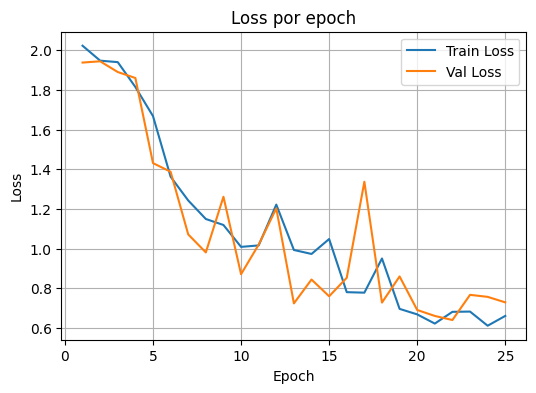

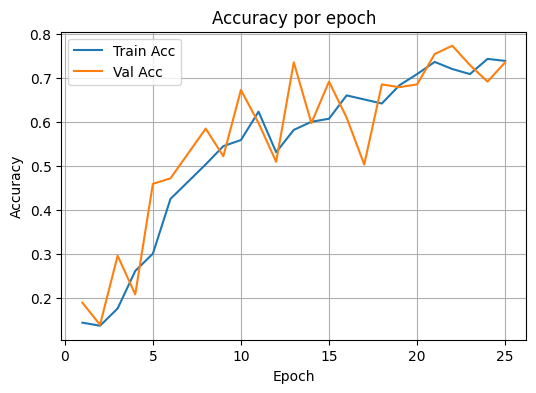

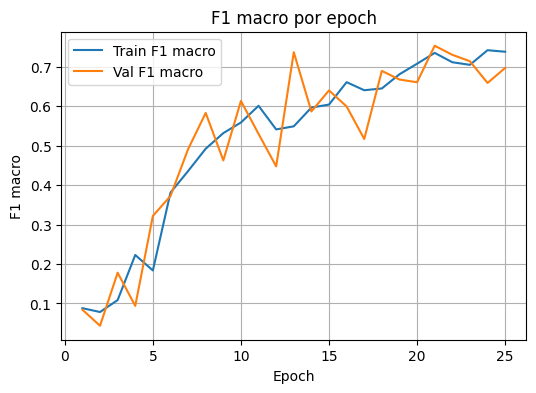

In [7]:
alexnet_random = alexnet(weights=None)
in_features = alexnet_random.classifier[-1].in_features
alexnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_random = alexnet_random.to(device)

num_epochs = 25

modo = 0
history = entrenar_modelo(alexnet_random, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Alexnet fine-tuning

Epoch [1/15] Train Loss: 1.5650  Val Loss: 0.9180  Train Acc: 0.4480  Val Acc: 0.7987  Train F1: 0.4566  Val F1: 0.8037
Epoch [2/15] Train Loss: 0.7249  Val Loss: 0.5345  Train Acc: 0.8476  Val Acc: 0.8805  Train F1: 0.8495  Val F1: 0.8820
Epoch [3/15] Train Loss: 0.4396  Val Loss: 0.3325  Train Acc: 0.9007  Val Acc: 0.9308  Train F1: 0.9013  Val F1: 0.9320
Epoch [4/15] Train Loss: 0.3107  Val Loss: 0.2673  Train Acc: 0.9330  Val Acc: 0.9434  Train F1: 0.9335  Val F1: 0.9451
Epoch [5/15] Train Loss: 0.2422  Val Loss: 0.2131  Train Acc: 0.9492  Val Acc: 0.9434  Train F1: 0.9494  Val F1: 0.9451
Epoch [6/15] Train Loss: 0.1875  Val Loss: 0.1880  Train Acc: 0.9584  Val Acc: 0.9371  Train F1: 0.9591  Val F1: 0.9386
Epoch [7/15] Train Loss: 0.1805  Val Loss: 0.1905  Train Acc: 0.9607  Val Acc: 0.9371  Train F1: 0.9610  Val F1: 0.9385
Epoch [8/15] Train Loss: 0.1507  Val Loss: 0.1817  Train Acc: 0.9515  Val Acc: 0.9371  Train F1: 0.9518  Val F1: 0.9387
Epoch [9/15] Train Loss: 0.1438  Val Los

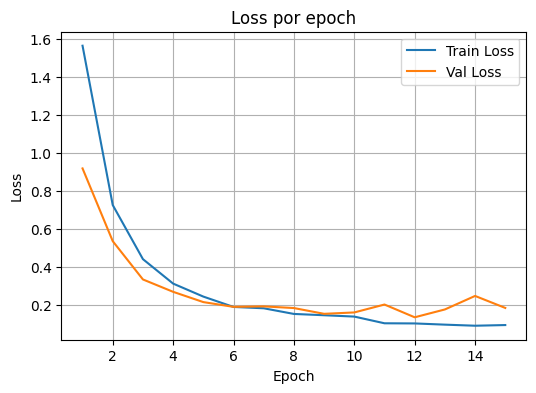

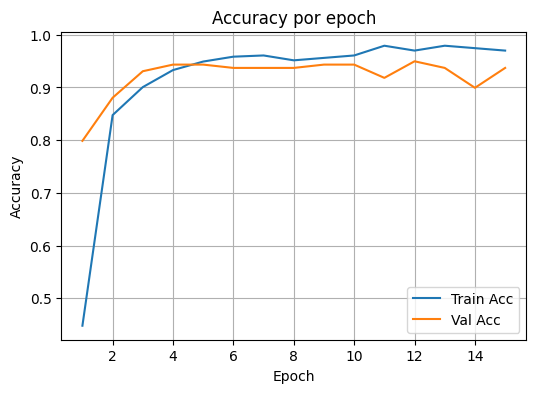

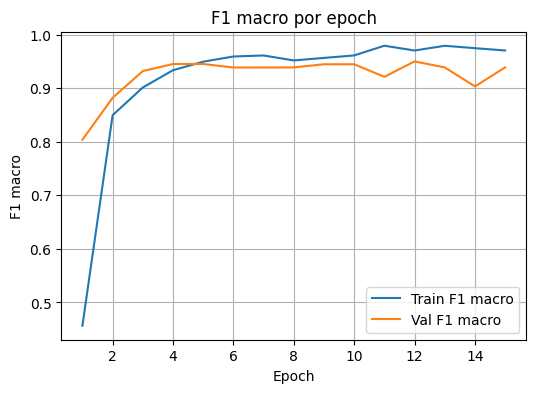

In [8]:
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)

num_epochs = 15

modo = 1
history = entrenar_modelo(alexnet_ft, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Alexnet feature extraction

Epoch [1/15] Train Loss: 0.7450  Val Loss: 0.3775  Train Acc: 0.7367  Val Acc: 0.8805  Train F1: 0.7373  Val F1: 0.8818
Epoch [2/15] Train Loss: 0.1790  Val Loss: 0.1732  Train Acc: 0.9515  Val Acc: 0.9308  Train F1: 0.9522  Val F1: 0.9308
Epoch [3/15] Train Loss: 0.1201  Val Loss: 0.1928  Train Acc: 0.9607  Val Acc: 0.9119  Train F1: 0.9608  Val F1: 0.9148
Epoch [4/15] Train Loss: 0.1023  Val Loss: 0.1588  Train Acc: 0.9607  Val Acc: 0.9371  Train F1: 0.9611  Val F1: 0.9382
Epoch [5/15] Train Loss: 0.0957  Val Loss: 0.1749  Train Acc: 0.9584  Val Acc: 0.9245  Train F1: 0.9583  Val F1: 0.9265
Epoch [6/15] Train Loss: 0.0834  Val Loss: 0.1576  Train Acc: 0.9769  Val Acc: 0.9371  Train F1: 0.9772  Val F1: 0.9382
Epoch [7/15] Train Loss: 0.0782  Val Loss: 0.1439  Train Acc: 0.9792  Val Acc: 0.9371  Train F1: 0.9793  Val F1: 0.9382
Epoch [8/15] Train Loss: 0.0569  Val Loss: 0.1518  Train Acc: 0.9792  Val Acc: 0.9245  Train F1: 0.9792  Val F1: 0.9265
Epoch [9/15] Train Loss: 0.0718  Val Los

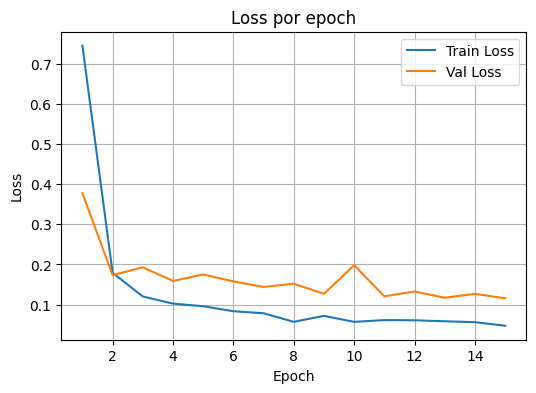

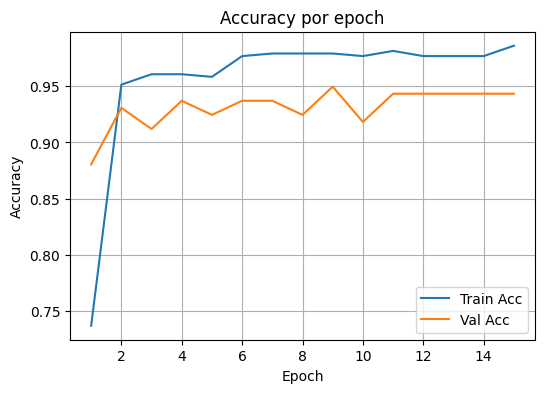

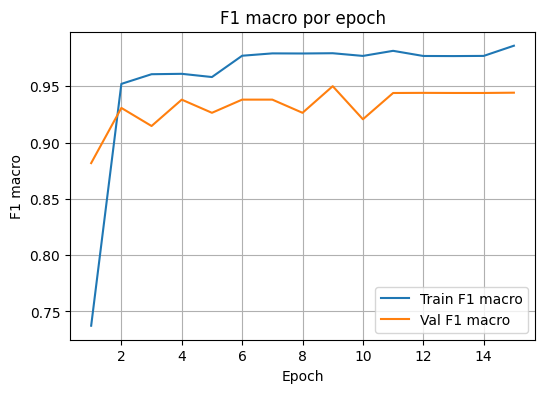

In [9]:
alexnet_fe = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
for p in alexnet_fe.parameters():
    p.requires_grad = False
in_features = alexnet_fe.classifier[-1].in_features
alexnet_fe.classifier[-1] = nn.Linear(in_features, num_classes)
for p in alexnet_fe.classifier[-1].parameters():
    p.requires_grad = True
alexnet_fe = alexnet_fe.to(device)

num_epochs = 15

modo = 0
history = entrenar_modelo(alexnet_fe, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Probando con otros modelos

In [10]:
from torchvision.models import resnet50, ResNet50_Weights, inception_v3, Inception_V3_Weights, efficientnet_v2_s, EfficientNet_V2_S_Weights

# Resnet entrenado desde cero

In [11]:
resnet_model = resnet50(weights=None)
resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Epoch [1/25] Train Loss: 2.3560  Val Loss: 2.4174  Train Acc: 0.2379  Val Acc: 0.1950  Train F1: 0.2356  Val F1: 0.0737
Epoch [2/25] Train Loss: 1.3825  Val Loss: 3.3519  Train Acc: 0.4804  Val Acc: 0.2390  Train F1: 0.4829  Val F1: 0.1097
Epoch [3/25] Train Loss: 1.0258  Val Loss: 1.7178  Train Acc: 0.6490  Val Acc: 0.4780  Train F1: 0.6460  Val F1: 0.4586
Epoch [4/25] Train Loss: 0.8636  Val Loss: 0.9001  Train Acc: 0.6674  Val Acc: 0.7358  Train F1: 0.6694  Val F1: 0.7335
Epoch [5/25] Train Loss: 0.7488  Val Loss: 0.8784  Train Acc: 0.6905  Val Acc: 0.7107  Train F1: 0.6924  Val F1: 0.7023
Epoch [6/25] Train Loss: 0.6891  Val Loss: 1.0932  Train Acc: 0.7737  Val Acc: 0.6289  Train F1: 0.7728  Val F1: 0.6099
Epoch [7/25] Train Loss: 0.5957  Val Loss: 1.1567  Train Acc: 0.8037  Val Acc: 0.7484  Train F1: 0.8060  Val F1: 0.7140
Epoch [8/25] Train Loss: 0.6679  Val Loss: 0.6066  Train Acc: 0.7552  Val Acc: 0.8239  Train F1: 0.7542  Val F1: 0.8217
Epoch [9/25] Train Loss: 0.5317  Val Los

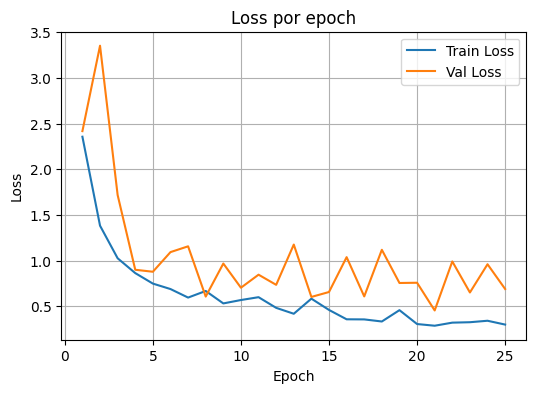

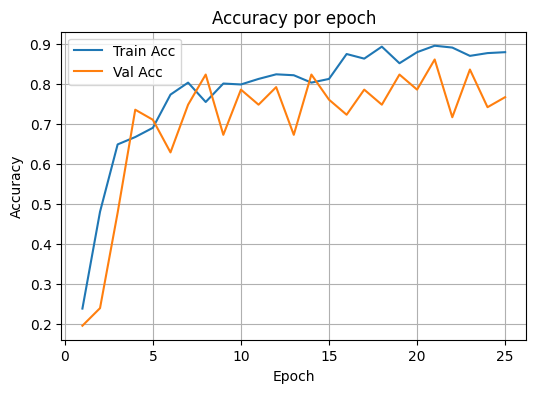

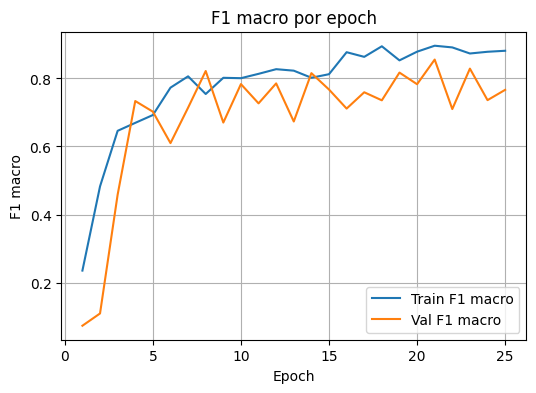

In [12]:
resnet_random = resnet50(weights=None)
in_features = resnet_random.fc.in_features
resnet_random.fc = nn.Linear(in_features, num_classes)
resnet_random = resnet_random.to(device)

num_epochs = 25

modo = 0
history = entrenar_modelo(resnet_random, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Resnet fine-tuning

Epoch [1/15] Train Loss: 1.8881  Val Loss: 1.7866  Train Acc: 0.2171  Val Acc: 0.3962  Train F1: 0.1895  Val F1: 0.3870
Epoch [2/15] Train Loss: 1.7399  Val Loss: 1.6589  Train Acc: 0.5358  Val Acc: 0.6289  Train F1: 0.5359  Val F1: 0.5973
Epoch [3/15] Train Loss: 1.6066  Val Loss: 1.5405  Train Acc: 0.7367  Val Acc: 0.7547  Train F1: 0.7340  Val F1: 0.7368
Epoch [4/15] Train Loss: 1.4807  Val Loss: 1.4294  Train Acc: 0.8360  Val Acc: 0.8050  Train F1: 0.8357  Val F1: 0.7914
Epoch [5/15] Train Loss: 1.3691  Val Loss: 1.3166  Train Acc: 0.8845  Val Acc: 0.8491  Train F1: 0.8845  Val F1: 0.8391
Epoch [6/15] Train Loss: 1.2755  Val Loss: 1.2090  Train Acc: 0.9099  Val Acc: 0.8868  Train F1: 0.9094  Val F1: 0.8773
Epoch [7/15] Train Loss: 1.1692  Val Loss: 1.1162  Train Acc: 0.9307  Val Acc: 0.9057  Train F1: 0.9302  Val F1: 0.9013
Epoch [8/15] Train Loss: 1.0653  Val Loss: 1.0299  Train Acc: 0.9215  Val Acc: 0.9245  Train F1: 0.9219  Val F1: 0.9218
Epoch [9/15] Train Loss: 0.9566  Val Los

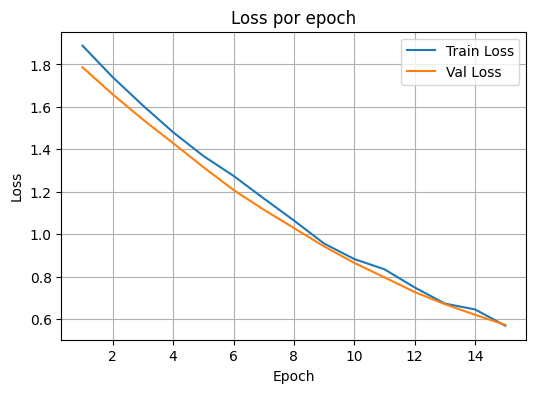

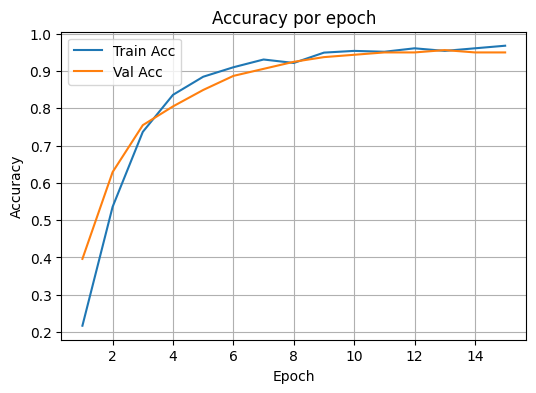

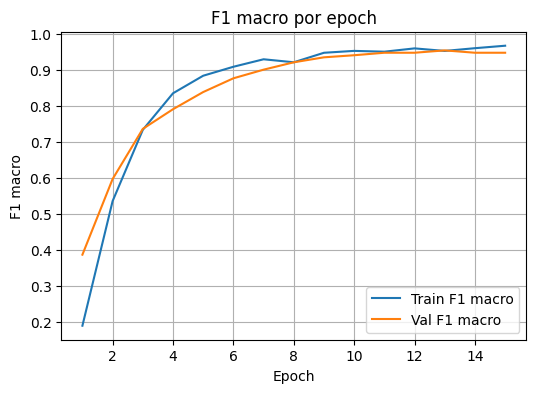

In [13]:
resnet_ft = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
in_features = resnet_random.fc.in_features
resnet_ft.fc = nn.Linear(in_features, num_classes)
resnet_ft = resnet_ft.to(device)

num_epochs = 15

modo = 1
history = entrenar_modelo(resnet_ft, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Resnet feature extraction

Epoch [1/15] Train Loss: 0.8576  Val Loss: 16.9947  Train Acc: 0.7714  Val Acc: 0.3836  Train F1: 0.7762  Val F1: 0.3503
Epoch [2/15] Train Loss: 0.4261  Val Loss: 6.1998  Train Acc: 0.8568  Val Acc: 0.3962  Train F1: 0.8585  Val F1: 0.3229
Epoch [3/15] Train Loss: 0.2847  Val Loss: 0.7378  Train Acc: 0.9261  Val Acc: 0.8113  Train F1: 0.9260  Val F1: 0.8091
Epoch [4/15] Train Loss: 0.2099  Val Loss: 0.4338  Train Acc: 0.9469  Val Acc: 0.8931  Train F1: 0.9466  Val F1: 0.8883
Epoch [5/15] Train Loss: 0.2481  Val Loss: 1.0834  Train Acc: 0.9330  Val Acc: 0.7107  Train F1: 0.9328  Val F1: 0.6653
Epoch [6/15] Train Loss: 0.2433  Val Loss: 0.3735  Train Acc: 0.9307  Val Acc: 0.8679  Train F1: 0.9307  Val F1: 0.8719
Epoch [7/15] Train Loss: 0.1923  Val Loss: 1.5039  Train Acc: 0.9330  Val Acc: 0.7925  Train F1: 0.9337  Val F1: 0.7935
Epoch [8/15] Train Loss: 0.1528  Val Loss: 0.2614  Train Acc: 0.9330  Val Acc: 0.9182  Train F1: 0.9340  Val F1: 0.9185
Epoch [9/15] Train Loss: 0.2415  Val Lo

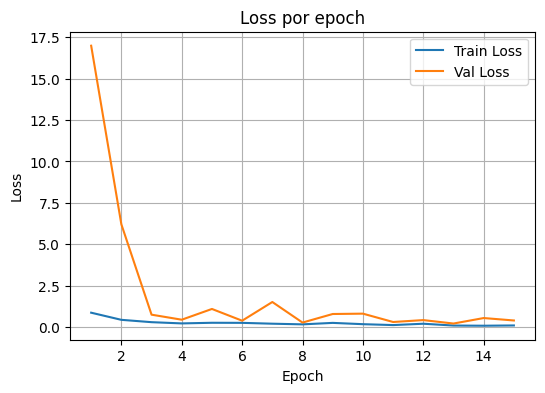

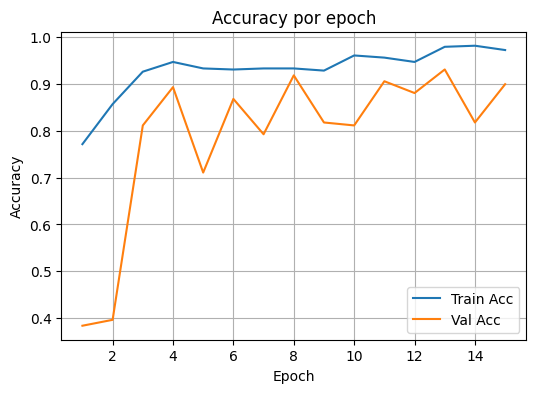

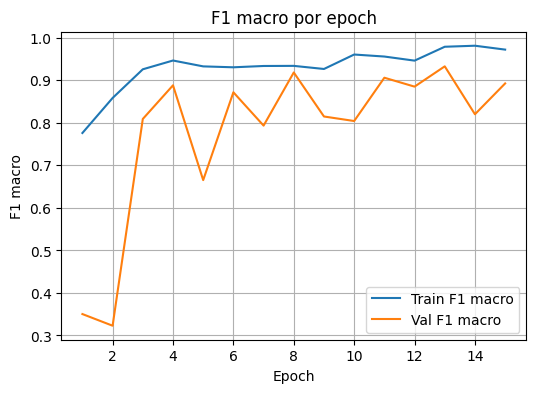

In [14]:
resnet_fe = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
for p in resnet_fe.parameters():
    p.requires_grad = False
in_features = resnet_fe.fc.in_features
resnet_fe.fc = nn.Linear(in_features, num_classes)
for p in resnet_fe.fc.parameters():
    p.requires_grad = True
resnet_fe = resnet_fe.to(device)

num_epochs = 15

modo = 0
history = entrenar_modelo(resnet_ft, train_loader, valid_loader, modo, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



# Testeo de resultados

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def infer_image(path_img, models, classes, model_names=None):
    if not isinstance(models, list):
        models = [models]

    assert len(models) <= 3, "Máximo 3 modelos permitidos"

    if model_names is None:
        model_names = [f"Modelo {i+1}" for i in range(len(models))]

    img = Image.open(path_img).convert("RGB")

    x = inference_transform(img).unsqueeze(0).to(device)

    all_probs = []
    predictions = []

    for model in models:
        model.eval()
        with torch.no_grad():
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

        all_probs.append(probs)

        predicted_idx = int(np.argmax(probs))
        predicted_class = classes[predicted_idx]
        predictions.append((predicted_class, probs[predicted_idx]))

    fig, axes = plt.subplots(1, len(models) + 1, figsize=(5 * (len(models) + 1), 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title("Imagen")

    for i, probs in enumerate(all_probs):
        ax = axes[i + 1]

        ax.bar(np.arange(len(classes)), probs * 100)
        ax.set_xticks(np.arange(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha="right")
        ax.set_ylabel("Prob (%)")
        ax.set_title(f"{model_names[i]}\n{predictions[i][0]} ({predictions[i][1]*100:.2f}%)")

        for j, p in enumerate(probs * 100):
            ax.text(j, p + 0.5, f"{p:.1f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

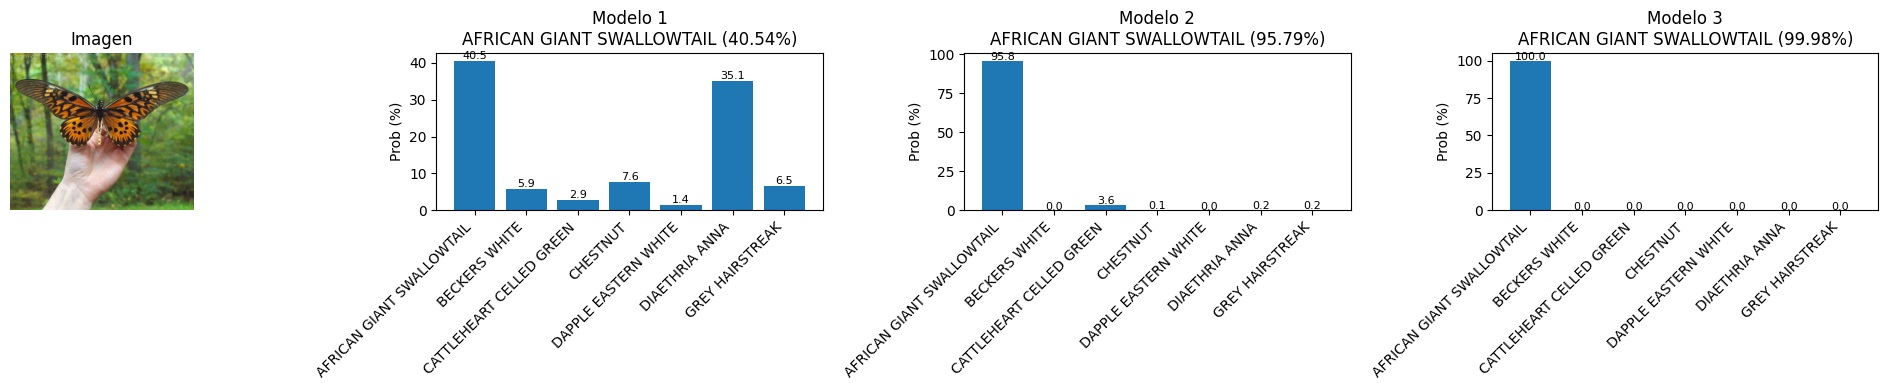

In [34]:
infer_image("/content/test/mariposa_gigante_africana.jpg", [alexnet_random, alexnet_ft, alexnet_fe], classes)

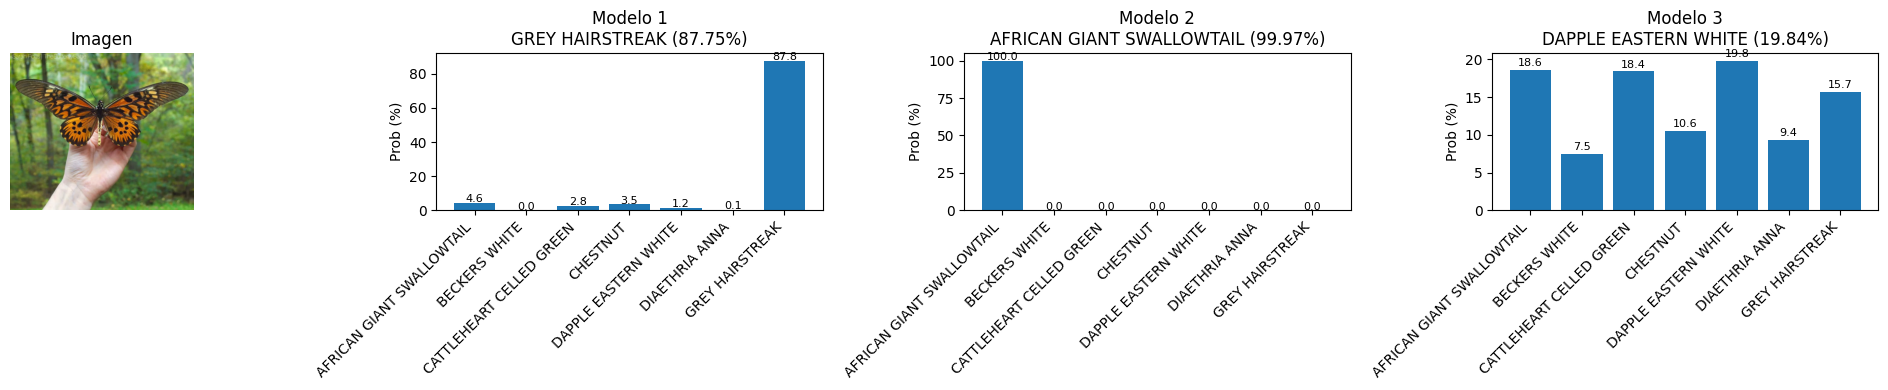

In [37]:
infer_image("/content/test/mariposa_gigante_africana.jpg", [resnet_random, resnet_ft, resnet_fe], classes)

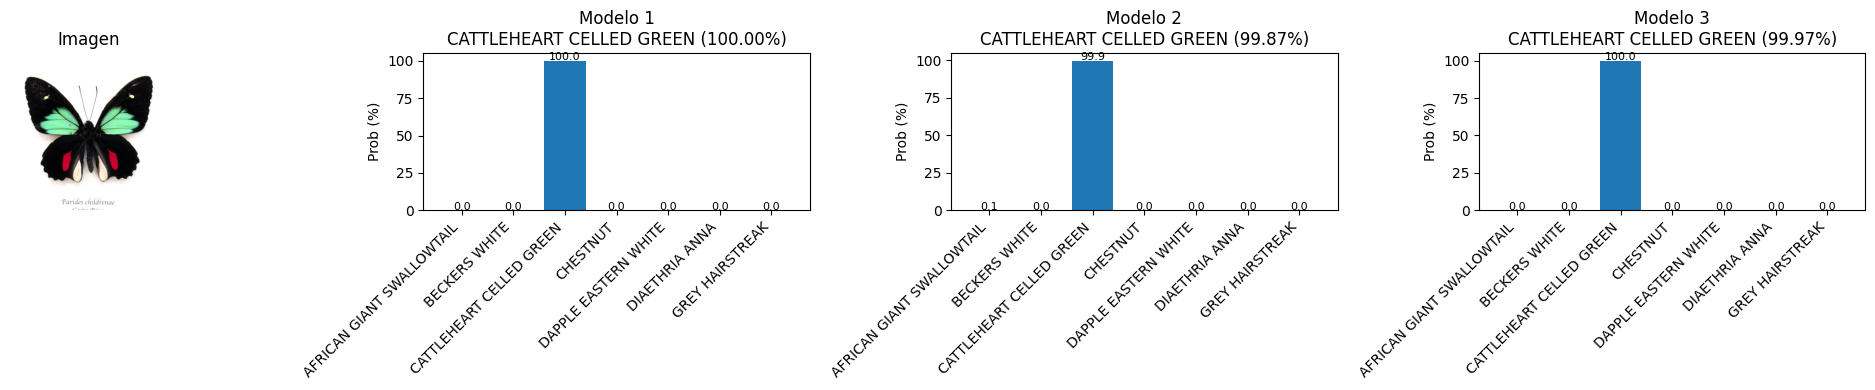

In [35]:
infer_image("/content/test/mariposa_attleheart_celled_green.jpg", [alexnet_random, alexnet_ft, alexnet_fe], classes)

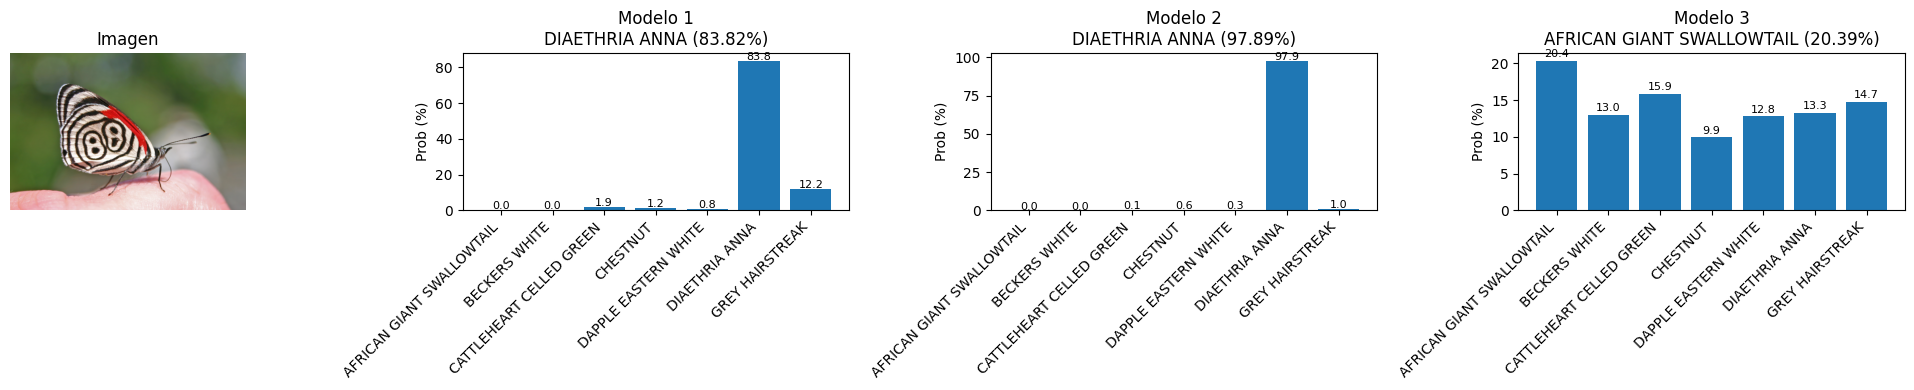

In [36]:
infer_image("/content/test/mariposa_diaethria_anna.jpg", [resnet_random, resnet_ft, resnet_fe], classes)

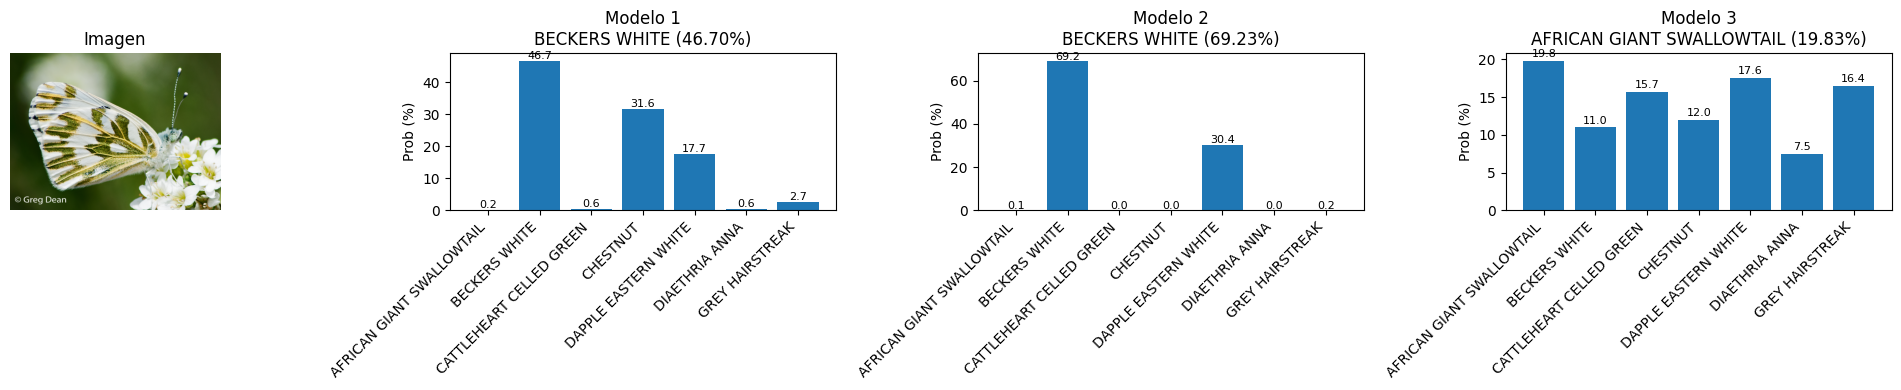

In [38]:
infer_image("/content/test/mariposa_beckers_white.jpg", [resnet_random, resnet_ft, resnet_fe], classes)